# Predicting Sales Prices

 ## Dataset Attributes

 The dataset contains information about houses in Ames, Iowa. The data was collected by the Ames City Assessor’s Office describing 2930 property sales which occurred in Ames, Iowa between 2006 and 2010. The dataset, containing 81 variables, was compiled and published by De Cock in 2011.

 Some of the variables contained in the original dataset have been removed from the the dataset provided to you.
 The dataset provided to you contains the following variables:
* **Year_Built:** year that the house was originally constructed
* **Year_Remod_Add:** year that the house was last remodelled
* **Total_Bsmt_SF:** total size of basement area in square feet
* **First_Flr_SF:** size of the first floor in square feet
* **Second_Flr_SF:** size of the second floor in square feet
* **Gr_Liv_Area:** size of above grade, ground living area in square feet
* **Full_Bath:** number of full above grade bathrooms in the house
* **Half_Bath:** number of half above grade bathrooms in the house
* **Bedroom_AbvGr:** number of above grade bedrooms (does not include basement bedrooms)
* **Kitchen_AbvGr:** number of above grade kitchens
* **TotRms_AbvGrd:** total number of above grade rooms (does not include bathrooms)
* **Fireplaces:** number of fireplaces in the house
* **Garage_Area:** size of garage in square feet
* **Sale_Price:** sale price of the house in dollars


*De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project," Journal of Statistics Education, Volume 19, Number 3.*

- https://ww2.amstat.org/publications/jse/v19n3/decock/DataDocumentation.txt
- http://ww2.amstat.org/publications/jse/v19n3/decock.pdf


 ## Objective

 The goal of this task is to analyse the relationship between these variables and build a multiple linear regression model to predict the sales prices based on the 'Gr_Liv_Area' and 'Garage_Area` variables.


In [ ]:
# Import libraries
import pandas as pd

In [ ]:
# Read in the data set
ames = pd.read_csv("ames.csv")
ames.head()

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
0,1960,1960,1080,1656,0,1656,1,0,3,1,7,2,528,215000
1,1961,1961,882,896,0,896,1,0,2,1,5,0,730,105000
2,1958,1958,1329,1329,0,1329,1,1,3,1,6,0,312,172000
3,1968,1968,2110,2110,0,2110,2,1,3,1,8,2,522,244000
4,1997,1998,928,928,701,1629,2,1,3,1,6,1,482,189900


In [2]:
# Clean and pre-process the data if necessary
required_columns = ["Gr_Liv_Area", "Garage_Area", "Sale_Price"]
print("Missing values before cleaning:")
print(ames[required_columns].isna().sum())

ames = ames.drop_duplicates().dropna(subset=required_columns).copy()
print(f"Dataset shape after cleaning: {ames.shape}")

Missing values before cleaning:
Gr_Liv_Area    0
Garage_Area    0
Sale_Price     0
dtype: int64
Dataset shape after cleaning: (2923, 14)


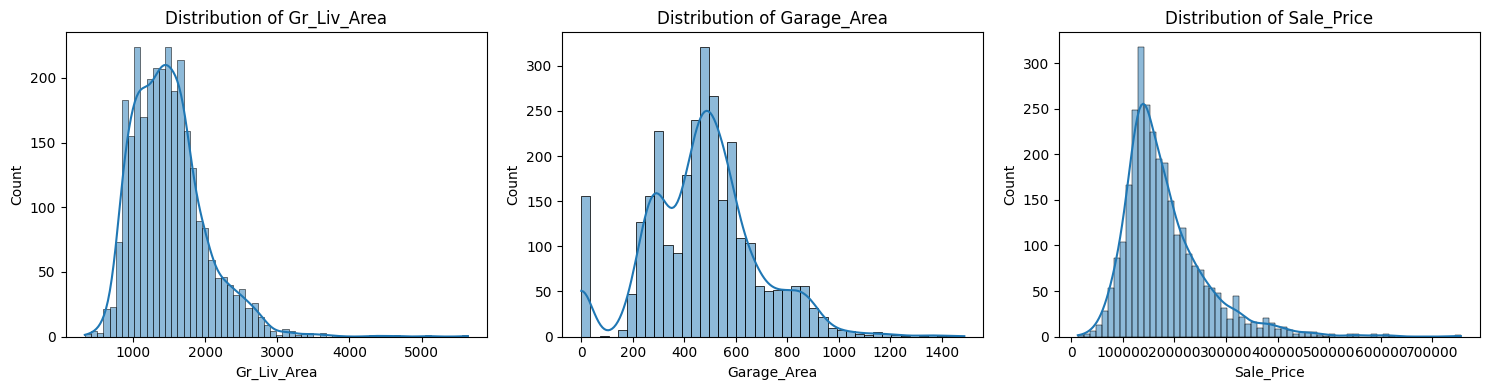

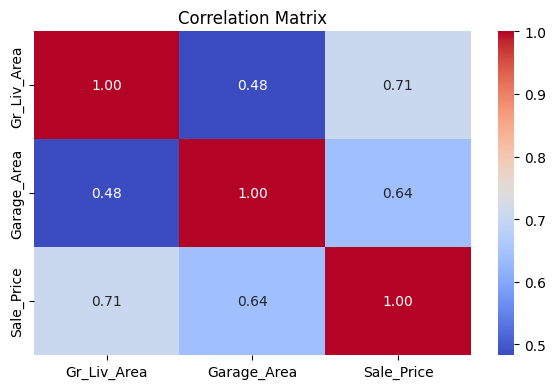

In [3]:
# Explore the data with visualisations such as histograms and correlation matrices
import matplotlib.pyplot as plt
import seaborn as sns

eda_columns = ["Gr_Liv_Area", "Garage_Area", "Sale_Price"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for axis, column in zip(axes, eda_columns):
    sns.histplot(ames[column], kde=True, ax=axis)
    axis.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(ames[eda_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [4]:
# Split the independent variables from the dependent variable
features = ["Gr_Liv_Area", "Garage_Area"]
X = ames[features]
y = ames["Sale_Price"]

print(f"Independent variables: {features}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Independent variables: ['Gr_Liv_Area', 'Garage_Area']
X shape: (2923, 2)
y shape: (2923,)


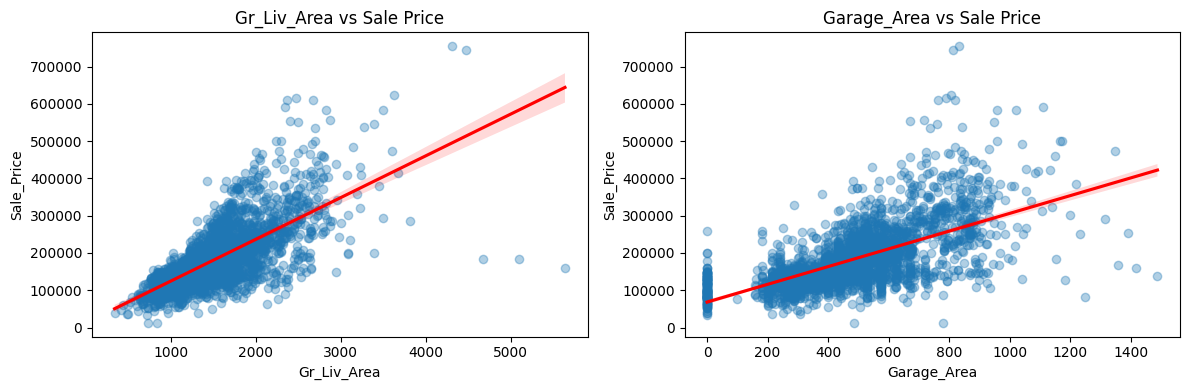

In [5]:
# Generate plots to explore the relationships between the independent and dependent variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for axis, feature in zip(axes, features):
    sns.regplot(data=ames, x=feature, y="Sale_Price", scatter_kws={"alpha": 0.35}, line_kws={"color": "red"}, ax=axis)
    axis.set_title(f"{feature} vs Sale Price")

plt.tight_layout()
plt.show()

In [6]:
# Create a training and test set with a 75:25 split ratio
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 2192 rows
Test set: 731 rows


In [7]:
# Build a multiple linear regression model using 'Gr_Liv_Area' and 'Garage_Area'
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 80.38,145.9 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Gr_Liv_Area','Garage_Area']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9648
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [8]:
# Print the trained model's intercept and coefficients
print(f"Intercept: {model.intercept_:,.2f}")
for feature, coefficient in zip(features, model.coef_):
    print(f"{feature} coefficient: {coefficient:,.2f}")

Intercept: -9,648.14
Gr_Liv_Area coefficient: 80.38
Garage_Area coefficient: 145.90


In [9]:
# Generate predictions for the test set
predictions = model.predict(X_test)

print(f"Generated {len(predictions)} predictions.")
print(f"First five predictions: {predictions[:5].round(2)}")

Generated 731 predictions.
First five predictions: [301217.98 250768.41  77157.22 196071.36 178402.33]


In [11]:
# Evaluate the model's performance by computing the mean squared error (MSE) or root mean squared error (RMSE) on the test set using sklearn.metrics.
import numpy as np
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"Mean squared error (MSE): {mse:,.2f}")
print(f"Root mean squared error (RMSE): ${rmse:,.2f}")

Mean squared error (MSE): 2,571,509,687.59
Root mean squared error (RMSE): $50,710.06


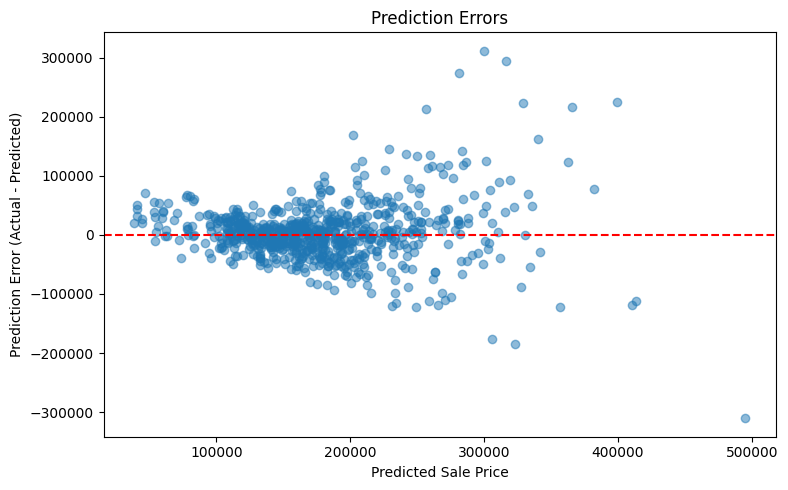

In [12]:
# Generate an error plot to visualise the differences between the predicted and actual values in the test set.
errors = y_test - predictions

plt.figure(figsize=(8, 5))
plt.scatter(predictions, errors, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Sale Price")
plt.ylabel("Prediction Error (Actual - Predicted)")
plt.title("Prediction Errors")
plt.tight_layout()
plt.show()

In [13]:
# Print the coefficients and interpret them within the context of the median value prediction.
print("Interpretation of coefficients:")
print(f"Holding Garage_Area constant, each additional square foot of Gr_Liv_Area is associated with an estimated increase of ${model.coef_[0]:,.2f} in Sale_Price.")
print(f"Holding Gr_Liv_Area constant, each additional square foot of Garage_Area is associated with an estimated increase of ${model.coef_[1]:,.2f} in Sale_Price.")
print(f"The fitted prediction equation is: Sale_Price = {model.intercept_:,.2f} + ({model.coef_[0]:,.2f} x Gr_Liv_Area) + ({model.coef_[1]:,.2f} x Garage_Area)")

Interpretation of coefficients:
Holding Garage_Area constant, each additional square foot of Gr_Liv_Area is associated with an estimated increase of $80.38 in Sale_Price.
Holding Gr_Liv_Area constant, each additional square foot of Garage_Area is associated with an estimated increase of $145.90 in Sale_Price.
The fitted prediction equation is: Sale_Price = -9,648.14 + (80.38 x Gr_Liv_Area) + (145.90 x Garage_Area)


**Interpret coefficients in the context of the prediction:**

The model estimates that, holding garage area constant, each additional square foot of above-grade living area is associated with an increase of approximately $80.38 in sale price. Holding living area constant, each additional square foot of garage area is associated with an increase of approximately $145.90 in sale price. These are associations from the fitted model, not guaranteed changes for an individual property.

**Summarise findings**

The cleaned Ames dataset contained 2,923 observations after duplicate rows were removed. Exploratory analysis showed right-skewed distributions for above-grade living area, garage area, and sale price. Sale price had positive correlations with Gr_Liv_Area (0.71) and Garage_Area (0.64), with living area showing the stronger individual relationship.

A multiple linear regression model using Gr_Liv_Area and Garage_Area was trained on 75% of the data and tested on the remaining 25%. The model produced an MSE of approximately 2,571,509,687.59 and an RMSE of approximately $50,710.06. The error plot showed several large errors and a wider spread at higher predicted prices, indicating that the two selected variables do not capture all factors affecting sale price.

For sales strategy, living area and garage area are useful indicators for pricing, but additional property features should be considered for more accurate valuations. The model should therefore support, rather than replace, professional pricing judgement.